# MatchIQ UCL — Hybrid AI Training & Evaluation

Notebook ini mendokumentasikan pipeline **UEFA Champions League** yang digunakan oleh
aplikasi Flask MatchIQ. Fokusnya bukan sekadar menghasilkan prediksi, tetapi membuat
proses data, feature engineering, training, evaluasi temporal, dan integrasi runtime
dapat diaudit serta direproduksi.

**Pipeline:** data UCL → fitur rolling/Elo time-aware → Dixon–Coles → XGBoost
terkalibrasi → Hybrid v3 (60% ML + 40% Dixon–Coles).

> Target 1X2 memakai skor setelah 90 menit. Notebook ini adalah eksperimen UCL terpisah;
> dataset klub tidak dicampur dengan model Piala Dunia.


## 0. Environment dan konfigurasi

Jalankan notebook memakai kernel **Python 3.12 (MatchIQ Hybrid AI)** dari folder proyek
MatchIQ. Pencarian root di bawah dibuat robust agar tetap bekerja ketika current working
directory berada di root proyek maupun folder `notebooks`.


In [1]:
from __future__ import annotations

import json
import platform
import sys
import warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "matchiq" / "engine.py").is_file() and (
            candidate / "data" / "ucl"
        ).is_dir():
            return candidate
    raise FileNotFoundError(
        "Root MatchIQ tidak ditemukan. Buka folder proyek MatchIQ di VS Code."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from matchiq.competitions import COMPETITIONS
from matchiq.engine import (
    ALL_FEATS_V3,
    FEAT_COLS_V3,
    MAX_GOALS,
    RANDOM_SEED,
    DixonColesModel,
    MatchIQEngine,
    ModelArtifactError,
    _load_training_matches,
    build_professional_features,
    build_runtime_artifact,
    matrix_outcome_probs,
)

UCL_SPEC = COMPETITIONS["ucl"]
DATA_PATH = UCL_SPEC.training_path(PROJECT_ROOT)
ALL_MATCHES_PATH = PROJECT_ROOT / "data/ucl/data/processed/ucl_matches_all.csv"
TEAMS_PATH = PROJECT_ROOT / "data/ucl/data/processed/ucl_teams.csv"
RUNTIME_PATH = UCL_SPEC.model_path(PROJECT_ROOT)
REPORT_PATH = PROJECT_ROOT / "data/ucl/reports/ucl_model_evaluation.json"
NOTEBOOK_REPORT_PATH = PROJECT_ROOT / "outputs/ucl_notebook_evaluation.json"

print(f"Project root : {PROJECT_ROOT}")
print(f"Python       : {platform.python_version()}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"XGBoost      : {xgboost.__version__}")
print(f"Dataset      : {DATA_PATH.relative_to(PROJECT_ROOT)}")


Project root : D:\Projects\MatchIQ
Python       : 3.12.10
pandas       : 2.3.3
scikit-learn : 1.8.0
XGBoost      : 3.4.1
Dataset      : data\ucl\data\processed\ucl_matches.csv


## 1. Memuat data dan memeriksa kontrak dataset

Dataset utama berisi pertandingan fase kompetisi UCL. File `ucl_matches_all.csv`
menambahkan kualifikasi yang tersedia, sedangkan training produksi memakai
`ucl_matches.csv` agar cakupan antarmusim konsisten.


In [2]:
raw_matches = pd.read_csv(DATA_PATH)
all_matches = pd.read_csv(ALL_MATCHES_PATH)
teams = pd.read_csv(TEAMS_PATH)
matches = _load_training_matches(PROJECT_ROOT, "ucl")

dataset_summary = pd.DataFrame(
    {
        "Nilai": [
            len(raw_matches),
            len(all_matches),
            teams["team_name"].nunique(),
            raw_matches["season"].nunique(),
            str(matches["date"].min().date()),
            str(matches["date"].max().date()),
        ]
    },
    index=[
        "Pertandingan utama",
        "Pertandingan termasuk kualifikasi",
        "Klub kanonis",
        "Musim",
        "Tanggal awal",
        "Tanggal akhir",
    ],
)
display(dataset_summary)
display(raw_matches.head(5))


,Nilai
Pertandingan utama,1997
Pertandingan termasuk kualifikasi,2179
Klub kanonis,161
Musim,15
Tanggal awal,2011-09-13
Tanggal akhir,2026-05-30


,match_id,competition,season,date,kickoff_time,kickoff_datetime,stage_raw,stage,stage_order,matchday,group,leg,is_qualifier,neutral,home_team_id,away_team_id,home_team,away_team,home_team_raw,away_team_raw,home_country_code,away_country_code,home_goals,away_goals,home_goals_final,away_goals_final,home_goals_ht,away_goals_ht,home_penalty,away_penalty,decided_by,result,total_goals,goal_diff,btts,home_elo_pre,away_elo_pre,elo_diff_pre,home_matches_before,away_matches_before,score_raw,source_file,source_line,source_commit
0,UCL-2011-12-M-0001,UEFA Champions League,2011-12,2011-09-13,20:45,2011-09-13T20:45:00,Group E,group_stage,3,NaN,E,not_applicable,0,0,ucl-chelsea-fc,ucl-bayer-leverkusen,Chelsea FC,Bayer Leverkusen,Chelsea FC,Bayer Leverkusen,ENG,GER,2,0,2,0,0.0000,0.0000,NaN,NaN,Normal Time,H,2,2,0,"1,500.0000","1,500.0000",65.0000,0,0,2-0 (0-0),2011-12/cl.txt,95,abfaeddc2ee3d14f99ecc163c9ddb46cb4d67cef
1,UCL-2011-12-M-0002,UEFA Champions League,2011-12,2011-09-13,20:45,2011-09-13T20:45:00,Group E,group_stage,3,NaN,E,not_applicable,0,0,ucl-krc-genk,ucl-valencia-cf,KRC Genk,Valencia CF,KRC Genk,Valencia CF,BEL,ESP,0,0,0,0,NaN,NaN,NaN,NaN,Normal Time,D,0,0,0,"1,500.0000","1,500.0000",65.0000,0,0,0-0,2011-12/cl.txt,96,abfaeddc2ee3d14f99ecc163c9ddb46cb4d67cef
2,UCL-2011-12-M-0003,UEFA Champions League,2011-12,2011-09-13,20:45,2011-09-13T20:45:00,Group F,group_stage,3,NaN,F,not_applicable,0,0,ucl-borussia-dortmund,ucl-arsenal-fc,Borussia Dortmund,Arsenal FC,Borussia Dortmund,Arsenal FC,GER,ENG,1,1,1,1,0.0000,1.0000,NaN,NaN,Normal Time,D,2,0,1,"1,500.0000","1,500.0000",65.0000,0,0,1-1 (0-1),2011-12/cl.txt,116,abfaeddc2ee3d14f99ecc163c9ddb46cb4d67cef
3,UCL-2011-12-M-0004,UEFA Champions League,2011-12,2011-09-13,20:45,2011-09-13T20:45:00,Group F,group_stage,3,NaN,F,not_applicable,0,0,ucl-olympiacos,ucl-olympique-marseille,Olympiacos,Olympique Marseille,Olympiakos Piraeus,Olympique Marseille,GRE,FRA,0,1,0,1,0.0000,0.0000,NaN,NaN,Normal Time,A,1,-1,0,"1,500.0000","1,500.0000",65.0000,0,0,0-1 (0-0),2011-12/cl.txt,117,abfaeddc2ee3d14f99ecc163c9ddb46cb4d67cef
4,UCL-2011-12-M-0005,UEFA Champions League,2011-12,2011-09-13,20:45,2011-09-13T20:45:00,Group G,group_stage,3,NaN,G,not_applicable,0,0,ucl-apoel-nikosia,ucl-zenit-st-petersburg,APOEL Nikosia,Zenit St. Petersburg,APOEL Nikosia,Zenit St. Petersburg,CYP,RUS,2,1,2,1,0.0000,0.0000,NaN,NaN,Normal Time,H,3,1,1,"1,500.0000","1,500.0000",65.0000,0,0,2-1 (0-0),2011-12/cl.txt,137,abfaeddc2ee3d14f99ecc163c9ddb46cb4d67cef


In [3]:
required_columns = [
    "match_id",
    "date",
    "season",
    "home_team",
    "away_team",
    "home_goals",
    "away_goals",
    "result",
]
missing_columns = sorted(set(required_columns) - set(raw_matches.columns))
missing_required_values = int(
    raw_matches[[column for column in required_columns if column in raw_matches]].isna().sum().sum()
)
duplicate_match_ids = int(raw_matches["match_id"].duplicated().sum())
invalid_scores = int(
    ((raw_matches["home_goals"] < 0) | (raw_matches["away_goals"] < 0)).sum()
)

checks = pd.DataFrame(
    [
        ("Kolom wajib hilang", 0, len(missing_columns)),
        ("Nilai wajib kosong", 0, missing_required_values),
        ("Match ID duplikat", 0, duplicate_match_ids),
        ("Skor negatif", 0, invalid_scores),
        ("Pertandingan utama", 1997, len(raw_matches)),
        ("Pertandingan seluruhnya", 2179, len(all_matches)),
        ("Klub kanonis", 161, teams["team_name"].nunique()),
        ("Jumlah musim", 15, raw_matches["season"].nunique()),
    ],
    columns=["Pemeriksaan", "Ekspektasi", "Aktual"],
)
checks["Status"] = np.where(checks["Ekspektasi"] == checks["Aktual"], "PASS", "FAIL")
display(checks)

assert missing_columns == [], missing_columns
assert (checks["Status"] == "PASS").all(), "Validasi dataset UCL gagal."
print("[OK] Kontrak dataset, ID pertandingan, skor, dan cakupan data valid.")


,Pemeriksaan,Ekspektasi,Aktual,Status
0,Kolom wajib hilang,0,0,PASS
1,Nilai wajib kosong,0,0,PASS
2,Match ID duplikat,0,0,PASS
3,Skor negatif,0,0,PASS
4,Pertandingan utama,1997,1997,PASS
5,Pertandingan seluruhnya,2179,2179,PASS
6,Klub kanonis,161,161,PASS
7,Jumlah musim,15,15,PASS


[OK] Kontrak dataset, ID pertandingan, skor, dan cakupan data valid.


## 2. Exploratory Data Analysis (EDA)

Grafik berikut memperlihatkan komposisi 1X2, distribusi total gol, dan jumlah laga per
musim. EDA dilakukan sebelum modeling untuk mendeteksi ketidakseimbangan kelas dan
perubahan volume kompetisi.


,matches,percent
result,,
Home,951,47.6200
Draw,409,20.4800
Away,637,31.9000


,total_goals
count,"1,997.0000"
mean,3.0336
std,1.7781
min,0.0000
25%,2.0000
50%,3.0000
75%,4.0000
max,12.0000


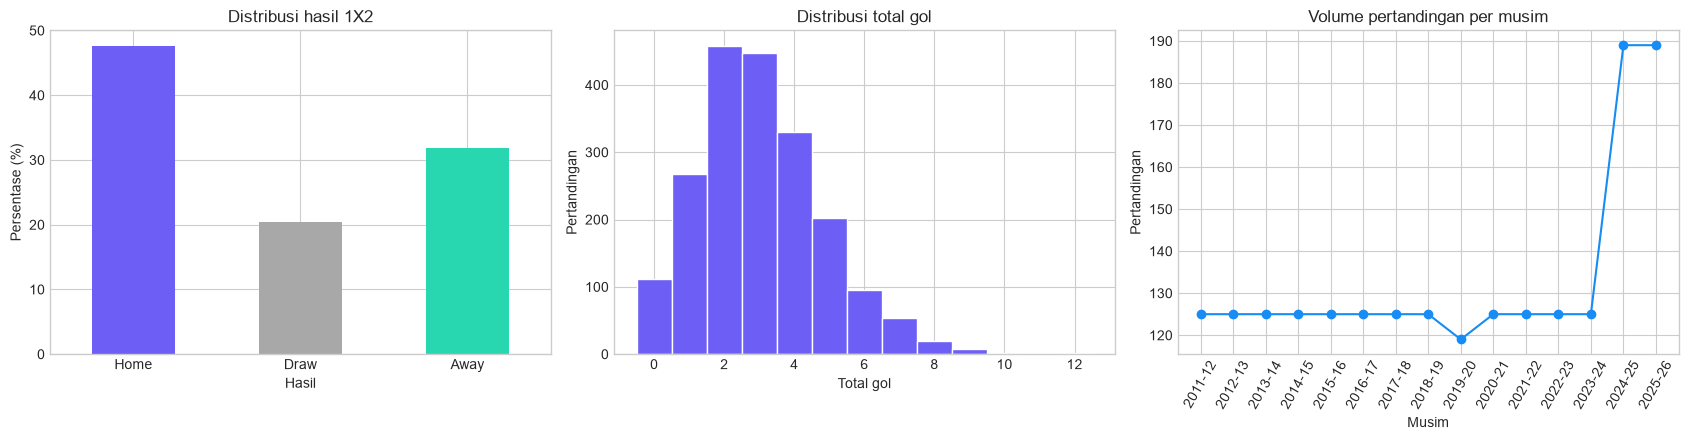

,team_name,association_code,matches,latest_elo
0,Real Madrid,ESP,182,"1,630.0700"
1,Bayern Munich,GER,173,"1,674.5400"
2,FC Barcelona,ESP,154,"1,607.2000"
3,Paris Saint-Germain,FRA,149,"1,652.4100"
4,Manchester City,ENG,145,"1,591.0200"
5,Atlético Madrid,ESP,131,"1,567.6200"
6,Borussia Dortmund,GER,130,"1,557.1600"
7,Juventus,ITA,120,"1,545.5200"
8,Benfica,POR,116,"1,509.5900"
9,Chelsea FC,ENG,106,"1,563.3700"


In [4]:
result_names = {"H": "Home", "D": "Draw", "A": "Away"}
result_distribution = (
    matches["result"].map(result_names).value_counts().reindex(["Home", "Draw", "Away"])
)
result_percent = (result_distribution / result_distribution.sum() * 100).round(2)
goal_summary = (matches["home_goals"] + matches["away_goals"]).describe().to_frame("total_goals")

display(pd.DataFrame({"matches": result_distribution, "percent": result_percent}))
display(goal_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
colors = ["#6D5EF5", "#A8A8A8", "#28D7B0"]
result_percent.plot.bar(ax=axes[0], color=colors, rot=0)
axes[0].set(title="Distribusi hasil 1X2", xlabel="Hasil", ylabel="Persentase (%)")

total_goals = matches["home_goals"] + matches["away_goals"]
bins = np.arange(0, int(total_goals.max()) + 2) - 0.5
axes[1].hist(total_goals, bins=bins, color="#6D5EF5", edgecolor="white")
axes[1].set(title="Distribusi total gol", xlabel="Total gol", ylabel="Pertandingan")

season_counts = matches.groupby("season", sort=False).size()
axes[2].plot(season_counts.index, season_counts.values, marker="o", color="#168CF4")
axes[2].tick_params(axis="x", rotation=60)
axes[2].set(title="Volume pertandingan per musim", xlabel="Musim", ylabel="Pertandingan")
plt.tight_layout()
plt.show()

top_clubs = teams.nlargest(12, "matches")[["team_name", "association_code", "matches", "latest_elo"]]
display(top_clubs.reset_index(drop=True))


## 3. Split temporal dan kontrol data leakage

Evaluasi tidak memakai random split. Musim **2025-26** ditahan sebagai test set dan
tidak digunakan untuk fitting model. Fitur form serta Elo dihitung berurutan: baris
pertandingan hanya membaca pertandingan yang sudah terjadi sebelumnya.

Untuk laga-laga berikutnya di musim test, fitur boleh memanfaatkan hasil laga test yang
sudah selesai. Ini merupakan simulasi **rolling-origin/online prediction**, bukan leakage.


In [5]:
HOLDOUT_SEASON = "2025-26"
train_mask = matches["season"].astype(str) != HOLDOUT_SEASON
test_mask = matches["season"].astype(str) == HOLDOUT_SEASON
train_matches = matches.loc[train_mask].copy()
test_matches = matches.loc[test_mask].copy()

split_summary = pd.DataFrame(
    [
        ("Train", ", ".join(sorted(train_matches["season"].unique())), len(train_matches),
         train_matches["date"].min().date(), train_matches["date"].max().date()),
        ("Test", HOLDOUT_SEASON, len(test_matches),
         test_matches["date"].min().date(), test_matches["date"].max().date()),
    ],
    columns=["Split", "Musim", "Pertandingan", "Tanggal awal", "Tanggal akhir"],
)
display(split_summary)

assert len(train_matches) == 1808
assert len(test_matches) == 189
assert train_matches["date"].max() < test_matches["date"].min()
print("[OK] Train/test terpisah secara kronologis.")


,Split,Musim,Pertandingan,Tanggal awal,Tanggal akhir
0,Train,"2011-12, 2012-13, 2013-14, 2014-15, 2015-16, 2...",1808,2011-09-13,2025-05-31
1,Test,2025-26,189,2025-09-16,2026-05-30


[OK] Train/test terpisah secara kronologis.


## 4. Feature engineering time-aware

Fitur meliputi rolling goals, kebobolan, form, BTTS, clean sheet, home/away split,
EWMA, variasi gol, attack index, dan Elo. Fungsi yang dipanggil sama dengan engine Flask.


In [6]:
professional, rolling_team_state = build_professional_features(matches)
feature_audit = professional[
    ["date", "home_team", "away_team", "result", *FEAT_COLS_V3]
].copy()

print(f"Fitur rolling/Elo : {len(FEAT_COLS_V3)}")
print(f"Baris fitur       : {len(feature_audit)}")
print(f"Nilai inf         : {int(np.isinf(feature_audit[FEAT_COLS_V3].to_numpy()).sum())}")
print(f"Nilai kosong      : {int(feature_audit[FEAT_COLS_V3].isna().sum().sum())}")
display(feature_audit.head(4))

assert len(professional) == len(matches)
assert not np.isinf(feature_audit[FEAT_COLS_V3].to_numpy()).any()


Fitur rolling/Elo : 33
Baris fitur       : 1997
Nilai inf         : 0
Nilai kosong      : 0


,date,home_team,away_team,result,h_avg_gs_5,h_avg_gs_10,h_avg_gc_5,h_avg_gc_10,a_avg_gs_5,a_avg_gs_10,a_avg_gc_5,a_avg_gc_10,h_ewma_gs,h_ewma_gc,a_ewma_gs,a_ewma_gc,h_form_5,h_form_10,a_form_5,a_form_10,h_btts_5,a_btts_5,h_cs_5,a_cs_5,h_home_gs_5,h_home_gc_5,a_away_gs_5,a_away_gc_5,h_gd_5,a_gd_5,h_attack_idx,a_attack_idx,elo_diff,h_elo,a_elo,h_gs_var,a_gs_var
0,2011-09-13,Chelsea FC,Bayer Leverkusen,H,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,"1,500.0000","1,500.0000",1.0000,1.0000
1,2011-09-13,KRC Genk,Valencia CF,D,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,"1,500.0000","1,500.0000",1.0000,1.0000
2,2011-09-13,Borussia Dortmund,Arsenal FC,D,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,"1,500.0000","1,500.0000",1.0000,1.0000
3,2011-09-13,Olympiacos,Olympique Marseille,A,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,"1,500.0000","1,500.0000",1.0000,1.0000


## 5. Dixon–Coles pada data train

Dixon–Coles memodelkan jumlah gol kandang/tandang dan memberi koreksi pada skor rendah.
Model di bawah hanya di-fit pada musim train. Probabilitas 1X2-nya kemudian menjadi tiga
fitur tambahan untuk classifier Hybrid v3.


In [7]:
dc_model = DixonColesModel(xi=0.0018, ridge=1e-3).fit(train_matches)

dc_rows = []
for _, match in matches.iterrows():
    matrix = dc_model.score_matrix(match["home_team"], match["away_team"], MAX_GOALS)
    probabilities = matrix_outcome_probs(matrix)
    dc_rows.append(
        {
            "dc_p_h": probabilities["H"],
            "dc_p_d": probabilities["D"],
            "dc_p_a": probabilities["A"],
        }
    )

modeling_frame = professional.join(pd.DataFrame(dc_rows, index=professional.index))
modeling_frame["y"] = modeling_frame["result"].map({"H": 0, "D": 1, "A": 2})

dc_diagnostics = pd.DataFrame(
    {
        "Nilai": [
            bool(dc_model.fit_result_.success),
            float(dc_model.fit_result_.fun),
            float(dc_model.rho_),
            len(dc_model.teams_),
        ]
    },
    index=["Optimizer success", "Negative log-likelihood", "Rho", "Tim terlatih"],
)
display(dc_diagnostics)
assert np.allclose(
    modeling_frame[["dc_p_h", "dc_p_d", "dc_p_a"]].sum(axis=1), 1.0, atol=1e-6
)


Dixon-Coles converged; negative log-likelihood=697.15


,Nilai
Optimizer success,True
Negative log-likelihood,697.1519
Rho,0.1214
Tim terlatih,104


## 6. Training XGBoost terkalibrasi dan Hybrid v3

Class weight dihitung dari data train. XGBoost dan calibrator tidak pernah menerima
target musim test. Probabilitas akhir Hybrid v3 adalah 60% ML dan 40% Dixon–Coles.


In [8]:
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

x_train = modeling_frame.loc[train_mask, ALL_FEATS_V3].fillna(0)
y_train = modeling_frame.loc[train_mask, "y"].astype(int).to_numpy()
x_test = modeling_frame.loc[test_mask, ALL_FEATS_V3].fillna(0)
y_test = modeling_frame.loc[test_mask, "y"].astype(int).to_numpy()

class_counts = Counter(y_train)
sample_weights = np.array(
    [len(y_train) / (3 * class_counts[label]) for label in y_train], dtype=float
)

base_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    verbosity=0,
)
calibrated_model = CalibratedClassifierCV(base_model, method="isotonic", cv=5)
calibrated_model.fit(x_train, y_train, sample_weight=sample_weights)

ml_probabilities = calibrated_model.predict_proba(x_test)
dc_probabilities = x_test[["dc_p_h", "dc_p_d", "dc_p_a"]].to_numpy()
hybrid_probabilities = 0.6 * ml_probabilities + 0.4 * dc_probabilities
hybrid_probabilities /= hybrid_probabilities.sum(axis=1, keepdims=True)

print(f"Train matrix : {x_train.shape}")
print(f"Test matrix  : {x_test.shape}")
print(f"Feature total: {len(ALL_FEATS_V3)}")
print("[OK] Training XGBoost terkalibrasi selesai.")


Train matrix : (1808, 36)
Test matrix  : (189, 36)
Feature total: 36
[OK] Training XGBoost terkalibrasi selesai.


## 7. Evaluasi temporal: baseline vs Dixon–Coles vs ML vs Hybrid

- **Accuracy** lebih besar lebih baik.
- **Log loss** dan **Brier score** lebih kecil lebih baik karena menilai kualitas
  probabilitas, bukan hanya kelas pemenang.


In [9]:
from sklearn.metrics import accuracy_score, log_loss

labels = [0, 1, 2]
one_hot = np.eye(3)[y_test]
class_prior = np.bincount(y_train, minlength=3) / len(y_train)
baseline_probabilities = np.tile(class_prior, (len(y_test), 1))


def probability_metrics(name: str, probabilities: np.ndarray) -> dict:
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities /= probabilities.sum(axis=1, keepdims=True)
    predictions = probabilities.argmax(axis=1)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Log loss": log_loss(y_test, probabilities, labels=labels),
        "Brier multiclass": np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)),
    }


evaluation_table = pd.DataFrame(
    [
        probability_metrics("Class-prior baseline", baseline_probabilities),
        probability_metrics("Dixon-Coles", dc_probabilities),
        probability_metrics("XGBoost calibrated", ml_probabilities),
        probability_metrics("Hybrid v3 (60/40)", hybrid_probabilities),
    ]
).set_index("Model")
display(evaluation_table.style.format("{:.4f}").highlight_min(
    subset=["Log loss", "Brier multiclass"], color="#d8f5e8"
).highlight_max(subset=["Accuracy"], color="#d8f5e8"))

hybrid_metrics = evaluation_table.loc["Hybrid v3 (60/40)"]
print(
    f"Hybrid holdout — accuracy={hybrid_metrics['Accuracy']:.4f}, "
    f"log_loss={hybrid_metrics['Log loss']:.4f}, "
    f"brier={hybrid_metrics['Brier multiclass']:.4f}"
)


,Accuracy,Log loss,Brier multiclass
Model,,,
Class-prior baseline,0.4974,1.0235,0.6174
Dixon-Coles,0.4709,1.1382,0.6696
XGBoost calibrated,0.4974,1.0227,0.6125
Hybrid v3 (60/40),0.5450,1.0055,0.6022


Hybrid holdout — accuracy=0.5450, log_loss=1.0055, brier=0.6022


## 8. Confusion matrix dan calibration curve

Confusion matrix menunjukkan kelas yang paling sering tertukar. Calibration curve
membandingkan probabilitas prediksi dengan frekuensi aktual untuk Home/Draw/Away.


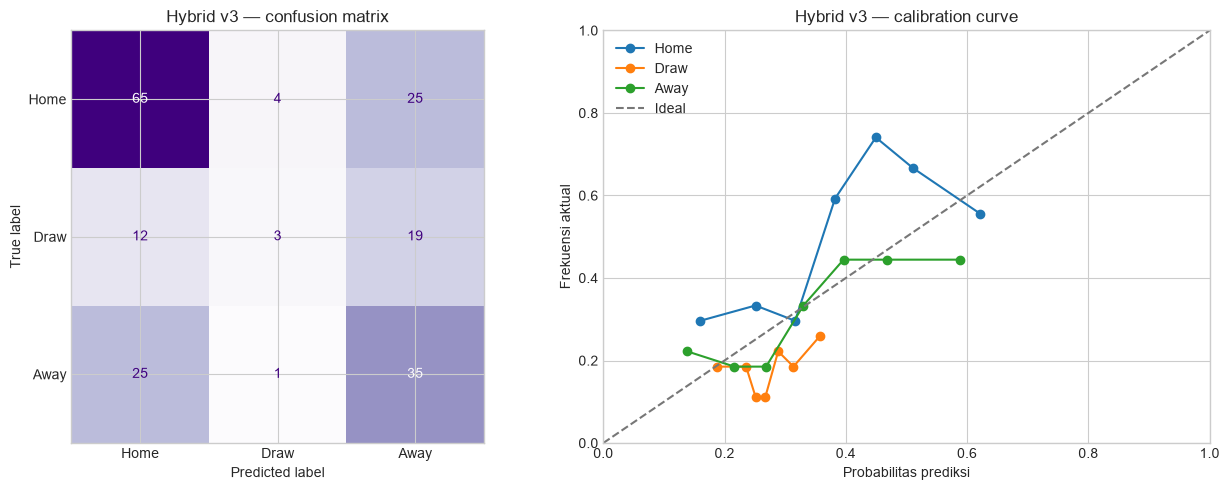

In [10]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

hybrid_predictions = hybrid_probabilities.argmax(axis=1)
class_names = ["Home", "Draw", "Away"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
matrix = confusion_matrix(y_test, hybrid_predictions, labels=labels)
ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(
    ax=axes[0], cmap="Purples", colorbar=False
)
axes[0].set_title("Hybrid v3 — confusion matrix")

for class_index, class_name in enumerate(class_names):
    observed, predicted = calibration_curve(
        (y_test == class_index).astype(int),
        hybrid_probabilities[:, class_index],
        n_bins=7,
        strategy="quantile",
    )
    axes[1].plot(predicted, observed, marker="o", label=class_name)
axes[1].plot([0, 1], [0, 1], "--", color="#777777", label="Ideal")
axes[1].set(
    title="Hybrid v3 — calibration curve",
    xlabel="Probabilitas prediksi",
    ylabel="Frekuensi aktual",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Feature importance dan error analysis

Importance dirata-ratakan dari estimator XGBoost pada seluruh fold kalibrasi.
Tabel error menampilkan kesalahan dengan confidence tertinggi sehingga kegagalan model
dapat diperiksa secara konkret.


,importance
elo_diff,0.0618
a_elo,0.0335
h_elo,0.0330
a_avg_gs_10,0.0315
h_gs_var,0.0301
a_ewma_gs,0.0296
a_gd_5,0.0294
h_gd_5,0.0289
h_ewma_gc,0.0281
h_avg_gs_10,0.0281


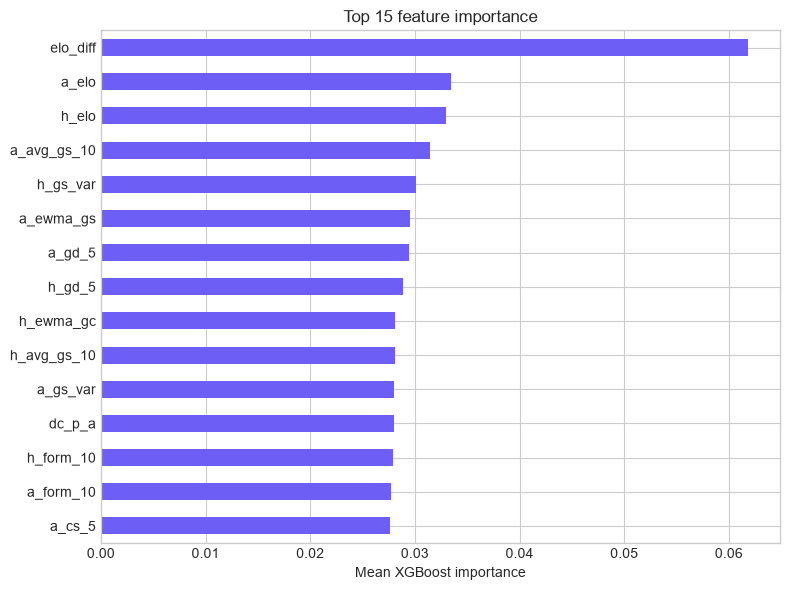

,date,home_team,away_team,home_goals,away_goals,result,prediction,confidence,p_home,p_draw,p_away,correct
159,2026-02-25,Paris Saint-Germain,AS Monaco,2,2,D,H,0.7583,0.7583,0.1647,0.0770,False
104,2025-12-10,Athletic Club,Paris Saint-Germain,0,0,D,A,0.6885,0.1018,0.2097,0.6885,False
63,2025-11-05,Benfica,Bayer Leverkusen,0,1,A,H,0.6639,0.6639,0.2304,0.1057,False
3,2025-09-16,Benfica,Qarabağ FK,2,3,A,H,0.6521,0.6521,0.2445,0.1034,False
67,2025-11-05,Club Brugge KV,FC Barcelona,3,3,D,A,0.6453,0.1670,0.1878,0.6453,False
183,2026-04-15,Arsenal FC,Sporting CP,0,0,D,H,0.6318,0.6318,0.2257,0.1425,False
129,2026-01-28,Borussia Dortmund,Inter Milan,0,2,A,H,0.6299,0.6299,0.2292,0.1408,False
133,2026-01-28,AFC Ajax,Olympiacos,1,2,A,H,0.6257,0.6257,0.2421,0.1322,False
134,2026-01-28,Atlético Madrid,FK Bodø/Glimt,1,2,A,H,0.6179,0.6179,0.2450,0.1370,False
164,2026-03-11,Bayer Leverkusen,Arsenal FC,1,1,D,A,0.6033,0.1512,0.2455,0.6033,False


In [11]:
fold_importances = []
for calibrated in getattr(calibrated_model, "calibrated_classifiers_", []):
    estimator = getattr(calibrated, "estimator", None)
    if estimator is not None and hasattr(estimator, "feature_importances_"):
        fold_importances.append(estimator.feature_importances_)

if fold_importances:
    importance = pd.Series(
        np.mean(fold_importances, axis=0), index=ALL_FEATS_V3, name="importance"
    ).sort_values(ascending=False)
    display(importance.head(15).to_frame())
    importance.head(15).sort_values().plot.barh(
        figsize=(8, 6), color="#6D5EF5", title="Top 15 feature importance"
    )
    plt.xlabel("Mean XGBoost importance")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance tidak tersedia pada versi estimator aktif.")

label_to_result = {0: "H", 1: "D", 2: "A"}
error_analysis = matches.loc[test_mask, [
    "date", "home_team", "away_team", "home_goals", "away_goals", "result"
]].reset_index(drop=True)
error_analysis["prediction"] = [label_to_result[value] for value in hybrid_predictions]
error_analysis["confidence"] = hybrid_probabilities.max(axis=1)
error_analysis["p_home"] = hybrid_probabilities[:, 0]
error_analysis["p_draw"] = hybrid_probabilities[:, 1]
error_analysis["p_away"] = hybrid_probabilities[:, 2]
error_analysis["correct"] = error_analysis["prediction"] == error_analysis["result"]

high_confidence_errors = (
    error_analysis.loc[~error_analysis["correct"]]
    .sort_values("confidence", ascending=False)
    .head(10)
)
display(high_confidence_errors)


## 10. Menyimpan laporan evaluasi notebook

Laporan JSON ringan menyimpan split, metrik, dan kontrol leakage. File ini bukan model;
runtime produksi tetap dibangun oleh `scripts/train_ucl_runtime.py` atau setup Windows.


In [12]:
notebook_report = {
    "status": "passed",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "competition": "ucl",
    "notebook": "notebooks/MatchIQ_UCL_Hybrid_AI_Training.ipynb",
    "split": {
        "train_seasons": sorted(str(value) for value in train_matches["season"].unique()),
        "test_season": HOLDOUT_SEASON,
        "train_matches": int(len(train_matches)),
        "test_matches": int(len(test_matches)),
    },
    "metrics": {
        model_name: {
            "accuracy": round(float(row["Accuracy"]), 6),
            "multiclass_log_loss": round(float(row["Log loss"]), 6),
            "multiclass_brier": round(float(row["Brier multiclass"]), 6),
        }
        for model_name, row in evaluation_table.iterrows()
    },
    "leakage_controls": [
        "Holdout season 2025-26 is excluded from model fitting.",
        "Rolling form and Elo features use only completed earlier matches.",
        "Production refit is separate from holdout evaluation.",
    ],
}
NOTEBOOK_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
NOTEBOOK_REPORT_PATH.write_text(
    json.dumps(notebook_report, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)
print(f"[OK] Laporan tersimpan: {NOTEBOOK_REPORT_PATH.relative_to(PROJECT_ROOT)}")
display(pd.DataFrame(notebook_report["metrics"]).T)


[OK] Laporan tersimpan: outputs\ucl_notebook_evaluation.json


,accuracy,multiclass_log_loss,multiclass_brier
Class-prior baseline,0.4974,1.0235,0.6174
Dixon-Coles,0.4709,1.1382,0.6696
XGBoost calibrated,0.4974,1.0227,0.6125
Hybrid v3 (60/40),0.5450,1.0055,0.6022


## 11. Uji integrasi runtime MatchIQ

Setelah `setup_windows.bat` dijalankan, cell ini memuat `models/ucl_runtime.joblib`
dan melakukan prediksi melalui class yang sama dengan API Flask. Jika runtime belum ada,
cell memberi instruksi dan tetap membiarkan notebook evaluasi selesai.


In [13]:
if RUNTIME_PATH.is_file():
    try:
        engine = MatchIQEngine(RUNTIME_PATH)
        sample = engine.predict("Real Madrid", "FC Barcelona", handicap=0)
        sample_summary = pd.DataFrame(
            {
                "Nilai": [
                    sample["headline"]["score"],
                    sample["one_x_two"]["home"],
                    sample["one_x_two"]["draw"],
                    sample["one_x_two"]["away"],
                    sample["expected_goals"]["home"],
                    sample["expected_goals"]["away"],
                    sample["model"]["training_matches"],
                    sample["model"]["data_until"],
                ]
            },
            index=[
                "Skor paling mungkin",
                "P(Home)",
                "P(Draw)",
                "P(Away)",
                "xG home",
                "xG away",
                "Pertandingan training",
                "Data sampai",
            ],
        )
        display(sample_summary)
        assert sample["competition"]["id"] == "ucl"
        assert abs(sum(sample["one_x_two"].values()) - 1.0) < 1e-4
        print("[OK] Runtime UCL dan kontrak prediksi Flask valid.")
    except ModelArtifactError as exc:
        print(f"Runtime ada tetapi tidak kompatibel: {exc}")
        print("Jalankan scripts/ensure_runtime_model.py lalu ulangi cell ini.")
else:
    print("Runtime UCL belum dibuat.")
    print("Windows: jalankan setup_windows.bat")
    print("Manual : python scripts/train_ucl_runtime.py")


,Nilai
Skor paling mungkin,2-1
P(Home),0.5362
P(Draw),0.1017
P(Away),0.3621
xG home,2.7460
xG away,1.8770
Pertandingan training,1997
Data sampai,2026-05-30


[OK] Runtime UCL dan kontrak prediksi Flask valid.


## 12. Refit produksi (opsional dan disengaja)

Evaluasi holdout di atas harus diselesaikan **sebelum** refit produksi. Setelah metrik
dicatat, runtime produksi boleh dilatih ulang memakai seluruh pertandingan selesai.

Ubah `REBUILD_PRODUCTION_RUNTIME` menjadi `True` hanya jika memang ingin menimpa runtime
UCL aktif pada komputer ini.


In [14]:
REBUILD_PRODUCTION_RUNTIME = False

if REBUILD_PRODUCTION_RUNTIME:
    production_metadata = build_runtime_artifact(
        PROJECT_ROOT,
        RUNTIME_PATH,
        competition_id="ucl",
    )
    display(pd.Series(production_metadata, name="production_runtime").to_frame())
    print(f"[OK] Runtime produksi diperbarui: {RUNTIME_PATH.relative_to(PROJECT_ROOT)}")
else:
    print("Refit produksi dilewati (aman).")
    print("Aktifkan hanya setelah evaluasi holdout diterima.")


Refit produksi dilewati (aman).
Aktifkan hanya setelah evaluasi holdout diterima.


## Kesimpulan dan batasan

Notebook ini memisahkan evaluasi temporal dari refit produksi dan memakai fungsi yang
sama dengan aplikasi MatchIQ. Dengan demikian, angka di notebook dapat ditelusuri sampai
ke dataset dan implementasi runtime.

Batasan penting:

- dataset belum memiliki xG, line-up, cedera, odds, atau performa liga domestik;
- Elo hanya dihitung dari pertandingan UCL yang tersedia;
- kualifikasi lengkap baru tersedia untuk dua musim terakhir dan tidak dipakai pada
  training utama;
- hasil adalah estimasi statistik, bukan kepastian dan bukan saran taruhan.

Untuk membangun ulang runtime UCL tanpa notebook:

```powershell
& "$env:LOCALAPPDATA\piala-dunia-26-hybrid-ai-v4-venv\Scripts\python.exe" .\scripts\train_ucl_runtime.py
```
